In [5]:
##Inicialización de LaTeX

!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,105 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,309 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,33

In [10]:
##Fase n°1 - Entrenamiento de la red neuronal

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 1. Cargar los datos
datos = np.load('datos_4098.npz')
# Convertimos los datos a jax.numpy arrays para optimizar operaciones en el dispositivo
X = jnp.array(datos['X'])
y = jnp.array(datos['y'])
t = jnp.array(datos['t'])

# 2. Definición de la Red Neuronal
def predict(params, X_batch):
    W1, W2 = params
    hidden = jnp.tanh(jnp.dot(X_batch, W1.T))
    X_hat = jnp.dot(hidden, W2.T)
    return X_hat

def mse_loss(params, X_batch):
    X_hat = predict(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

# 3. Inicialización de Pesos
def init_fourier(t_vec, key, K=30):
    # Optimización: Creación vectorizada de la base de Fourier
    # Convertimos t_vec a numpy normal para la inicialización (evita uso innecesario de la GPU aquí)
    t_np = np.array(t_vec)
    k_vals = np.arange(1, K + 1)[:, None]
    t_vals = t_np[None, :]
    args = 2 * np.pi * k_vals * t_vals

    W1 = np.empty((2 * K, len(t_np)))
    W1[0::2, :] = np.sin(args)  # Índices pares: Senos
    W1[1::2, :] = np.cos(args)  # Índices impares: Cosenos

    key_w2, _ = jax.random.split(key)
    W2 = jax.random.normal(key_w2, (len(t_np), 2 * K)) * 0.1

    return [jnp.array(W1), W2]

def init_random(t_vec, key, K=30):
    key_w1, key_w2 = jax.random.split(key)
    W1 = jax.random.normal(key_w1, (2 * K, len(t_vec))) * 0.1
    W2 = jax.random.normal(key_w2, (len(t_vec), 2 * K)) * 0.1
    return [W1, W2]

# 4. Ciclo de Entrenamiento
@jax.jit
def update(params, X_batch, lr=0.1):
    loss, grads = jax.value_and_grad(mse_loss)(params, X_batch)
    # Optimización: tree_map es la forma canónica de actualizar PyTrees en JAX
    new_params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)
    return new_params, loss

def train_network(params, X_train, epochs=2000, lr=0.1):
    loss_history = []
    for epoch in range(epochs):
        params, loss = update(params, X_train, lr)
        # Corrección: Extraer el valor escalar para evitar fugas de memoria
        loss_history.append(float(loss))
    return params, loss_history

# 5. Ejecución del Experimento

# Entrenar para el régimen 0
X_regimen_0 = X[y == 0]
key_r0, key_r0_fourier, key_r0_random = jax.random.split(jax.random.PRNGKey(4098), 3)

params_fourier_r0 = init_fourier(t, key_r0_fourier)
params_fourier_final_r0, loss_fourier_r0 = train_network(params_fourier_r0, X_regimen_0, epochs=2000, lr=0.1)

params_random_r0 = init_random(t, key_r0_random)
params_random_final_r0, loss_random_r0 = train_network(params_random_r0, X_regimen_0, epochs=2000, lr=0.1)

# Entrenar para el régimen 1
X_regimen_1 = X[y == 1]
key_r1, key_r1_fourier, key_r1_random = jax.random.split(jax.random.PRNGKey(4098), 3)

params_fourier_r1 = init_fourier(t, key_r1_fourier)
params_fourier_final_r1, loss_fourier_r1 = train_network(params_fourier_r1, X_regimen_1, epochs=2000, lr=0.1)

params_random_r1 = init_random(t, key_r1_random)
params_random_final_r1, loss_random_r1 = train_network(params_random_r1, X_regimen_1, epochs=2000, lr=0.1)

# Entrenar para el régimen 2
X_regimen_2 = X[y == 2]
key_r2, key_r2_fourier, key_r2_random = jax.random.split(jax.random.PRNGKey(4098), 3)

params_fourier_r2 = init_fourier(t, key_r2_fourier)
params_fourier_final_r2, loss_fourier_r2 = train_network(params_fourier_r2, X_regimen_2, epochs=2000, lr=0.1)

params_random_r2 = init_random(t, key_r2_random)
params_random_final_r2, loss_random_r2 = train_network(params_random_r2, X_regimen_2, epochs=2000, lr=0.1)


Energía media del dataset (X**2).mean(): 0.7120


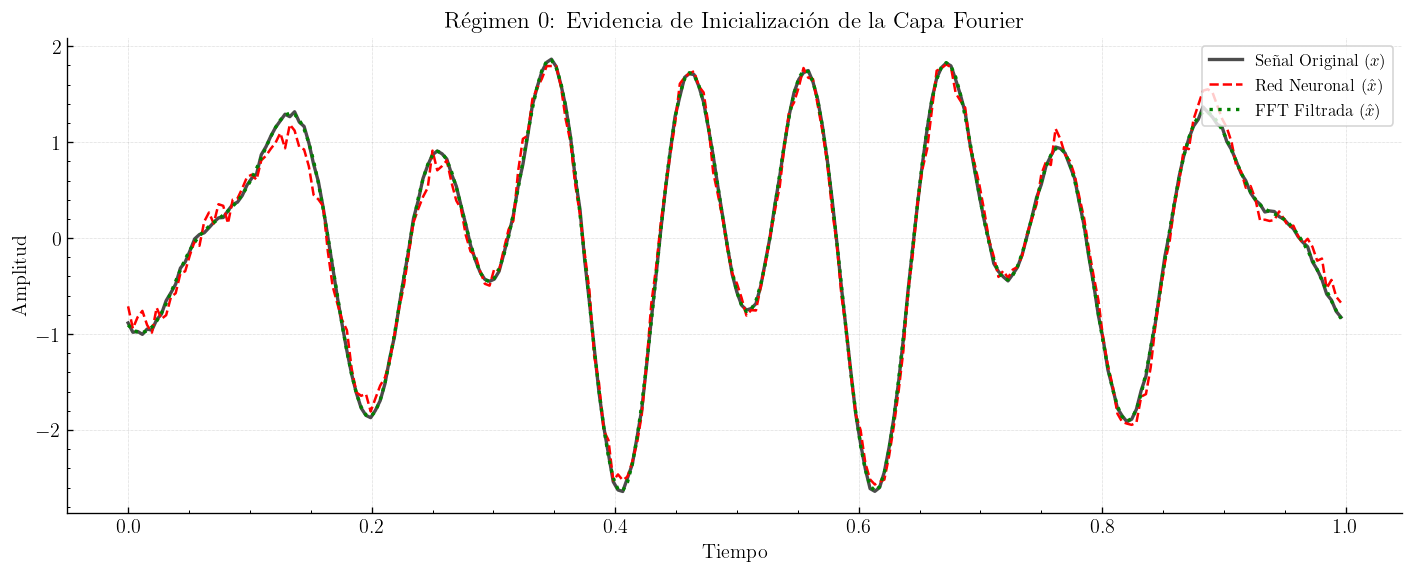

In [11]:
##Fase n°2 - Verificación inicial del entrenamiento

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Seleccionar una señal de ejemplo del régimen 0
sample_signal_idx = 0
original_signal = X_regimen_0[sample_signal_idx]

# 1. Reconstrucción con la red neuronal (inicialización Fourier)
# Aseguramos que pasamos un array de JAX con el formato de lote (1, 256)
x_input = jnp.expand_dims(jnp.array(original_signal), axis=0)
reconstructed_nn = predict(params_fourier_final_r0, x_input)[0]

# 2. Reconstrucción utilizando FFT clásica
N = len(original_signal)
dt = t[1] - t[0]

# Calcular la FFT de la señal original
fft_original = np.fft.fft(original_signal)
frequencies = np.fft.fftfreq(N, d=float(dt))

# Crear un array para la FFT filtrada, inicializado a cero
filtered_fft = np.zeros_like(fft_original, dtype=complex)

# Extraer las frecuencias utilizadas en la construcción de W1
K_fourier = 30 # Definido en init_fourier
basis_freqs = np.arange(1, K_fourier + 1)

# Filtrar usando el índice más cercano (Nearest Bin) para evitar problemas de precisión
for freq in basis_freqs:
    # Índice de la frecuencia positiva
    idx_pos = np.argmin(np.abs(frequencies - freq))
    filtered_fft[idx_pos] = fft_original[idx_pos]

    # Índice de la frecuencia negativa conjugada
    idx_neg = np.argmin(np.abs(frequencies - (-freq)))
    filtered_fft[idx_neg] = fft_original[idx_neg]

# Realizar la IFFT para obtener la señal reconstruida
reconstructed_fft = np.fft.ifft(filtered_fft).real

# Reportar la energía media del dataset X
print(f"Energía media del dataset (X**2).mean(): {jnp.mean(X**2):.4f}")

# 4. Visualización
plt.figure(figsize=(12, 5))
plt.plot(t, original_signal, label="Señal Original ($x$)", color='black', alpha=0.7, linewidth=2)
plt.plot(t, reconstructed_nn, label=r"Red Neuronal ($\hat{x}$)", color='red', linestyle='--', linewidth=1.5)
plt.plot(t, reconstructed_fft, label=r"FFT Filtrada ($\hat{x}$)", color='green', linestyle=':', linewidth=2)

plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Amplitud", fontsize=12)
plt.title("Régimen 0: Evidencia de Inicialización de la Capa Fourier", fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Reporte de Error de Reconstrucción Relativo |x_hat - x| / |x|
-----------------------------------------------------------------
Régimen 0:
  -> Error relativo (Fourier):   0.1395
  -> Error relativo (Aleatoria): 0.1297



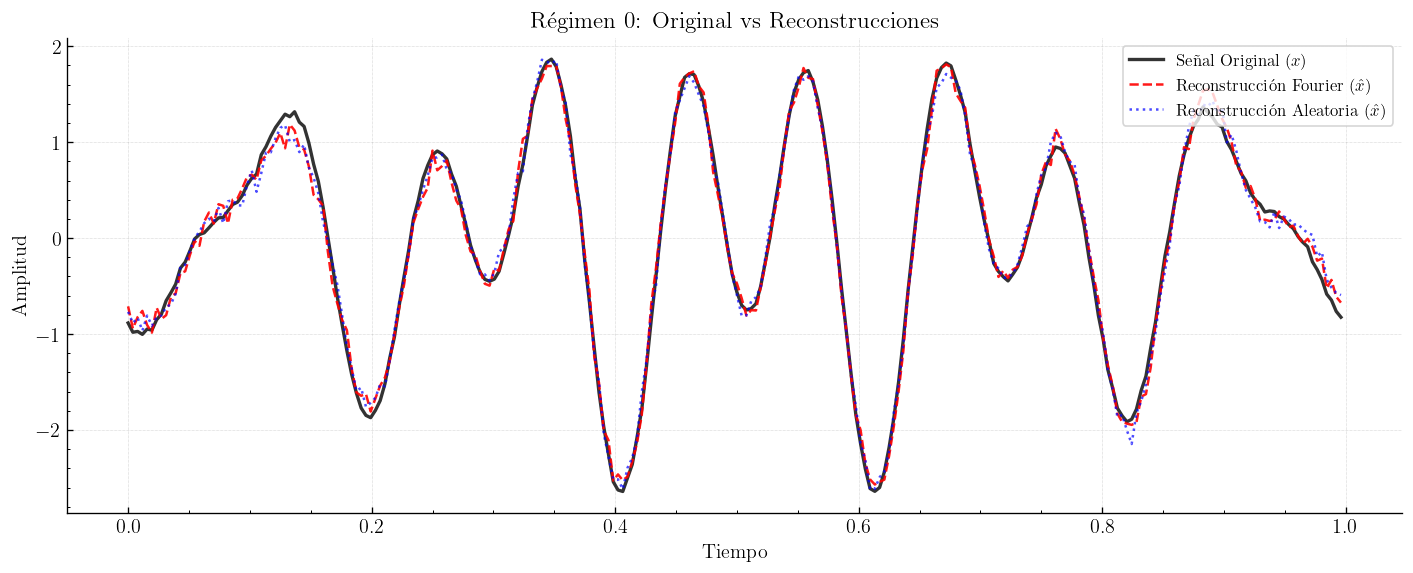

Régimen 1:
  -> Error relativo (Fourier):   0.1172
  -> Error relativo (Aleatoria): 0.1227



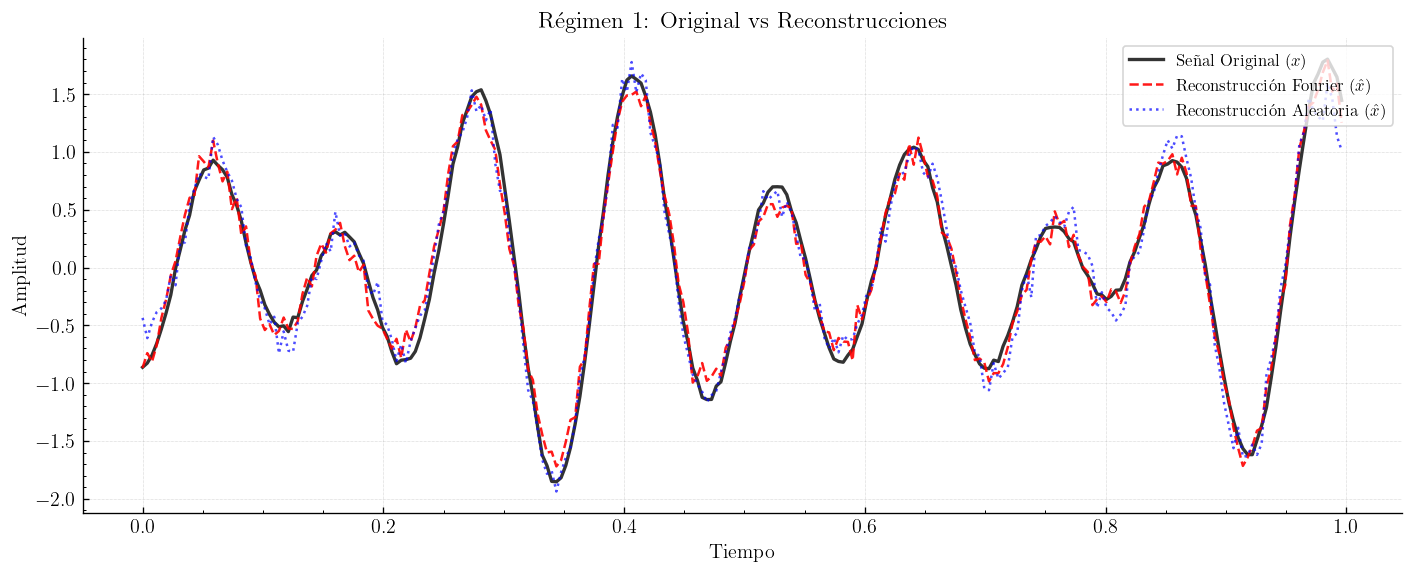

Régimen 2:
  -> Error relativo (Fourier):   0.1683
  -> Error relativo (Aleatoria): 0.1483



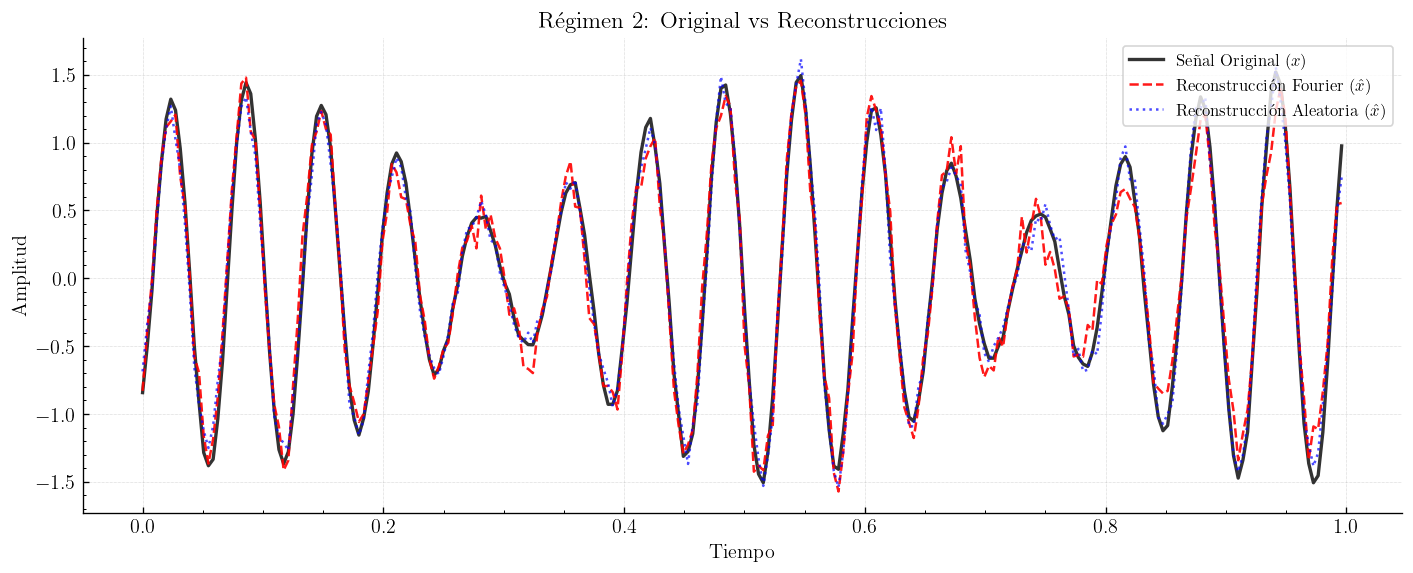

In [13]:
##Fase n°3 - Comparación de las redes entrenadas

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Ubicar parametros de cada regimen
fourier_params_map = {
    0: params_fourier_final_r0,
    1: params_fourier_final_r1,
    2: params_fourier_final_r2,
}

random_params_map = {
    0: params_random_final_r0,
    1: params_random_final_r1,
    2: params_random_final_r2,
}

# Obtener los regímenes únicos presentes en los datos
unique_regimes = np.unique(y)

print("Reporte de Error de Reconstrucción Relativo |x_hat - x| / |x|")
print("-" * 65)

for regime in unique_regimes:
    # 1. Encontrar índices y extraer la primera señal de ejemplo
    regime_indices = np.where(y == regime)[0]
    if len(regime_indices) == 0:
        continue

    sample_index = regime_indices[0]
    original_signal = X[sample_index]

    # Formato de lote (1, 256) para la función predict
    x_input = jnp.expand_dims(jnp.array(original_signal), axis=0)

    # Parametros especificos del regimen
    current_fourier_params = fourier_params_map.get(regime)
    current_random_params = random_params_map.get(regime)

    # 2. Reconstrucción con ambas redes
    reconstructed_fourier = predict(current_fourier_params, x_input)[0]
    reconstructed_random = predict(current_random_params, x_input)[0]

    # 3. Cálculo del Error Relativo (|x_hat - x| / |x|)

    # Usamos la norma L2 (jnp.linalg.norm) que es la interpretación estándar para vectores

    # En lugar de tomar una sola señal, tomamos TODAS las señales de este régimen
    x_input_batch = jnp.array(X[regime_indices])

    # Reconstrucción del lote completo
    reconstructed_fourier_batch = predict(current_fourier_params, x_input_batch)
    reconstructed_random_batch = predict(current_random_params, x_input_batch)

    # Cálculo del Error Relativo Global para todo el régimen
    norm_original_batch = jnp.linalg.norm(x_input_batch)
    error_relativo_fourier = jnp.linalg.norm(reconstructed_fourier_batch - x_input_batch) / norm_original_batch
    error_relativo_random = jnp.linalg.norm(reconstructed_random_batch - x_input_batch) / norm_original_batch

    print(f"Régimen {regime}:")
    print(f"  -> Error relativo (Fourier):   {float(error_relativo_fourier):.4f}")
    print(f"  -> Error relativo (Aleatoria): {float(error_relativo_random):.4f}\n")

    # 4. Gráfica: La señal original junto a su reconstrucción final
    plt.figure(figsize=(12, 5))

    # Se superponen las señales tal como pide la sección "Entrenamiento y reconstrucción"
    plt.plot(t, original_signal, label='Señal Original ($x$)', color='black', alpha=0.8, linewidth=2)
    plt.plot(t, reconstructed_fourier, label=r'Reconstrucción Fourier ($\hat{x}$)', color='red', linestyle='--', alpha=0.9)
    plt.plot(t, reconstructed_random, label=r'Reconstrucción Aleatoria ($\hat{x}$)', color='blue', linestyle=':', alpha=0.7)

    plt.title(f'Régimen {regime}: Original vs Reconstrucciones', fontsize=14)
    plt.xlabel('Tiempo', fontsize=12)
    plt.ylabel('Amplitud', fontsize=12)

    # Leyenda clara para visualización
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

Análisis de Convergencia (Régimen 0)
-------------------------------------------------------
Iteraciones para Error Relativo < 0.1:
  -> Inicialización Fourier:  No alcanzó el umbral
  -> Inicialización Aleatoria: No alcanzó el umbral



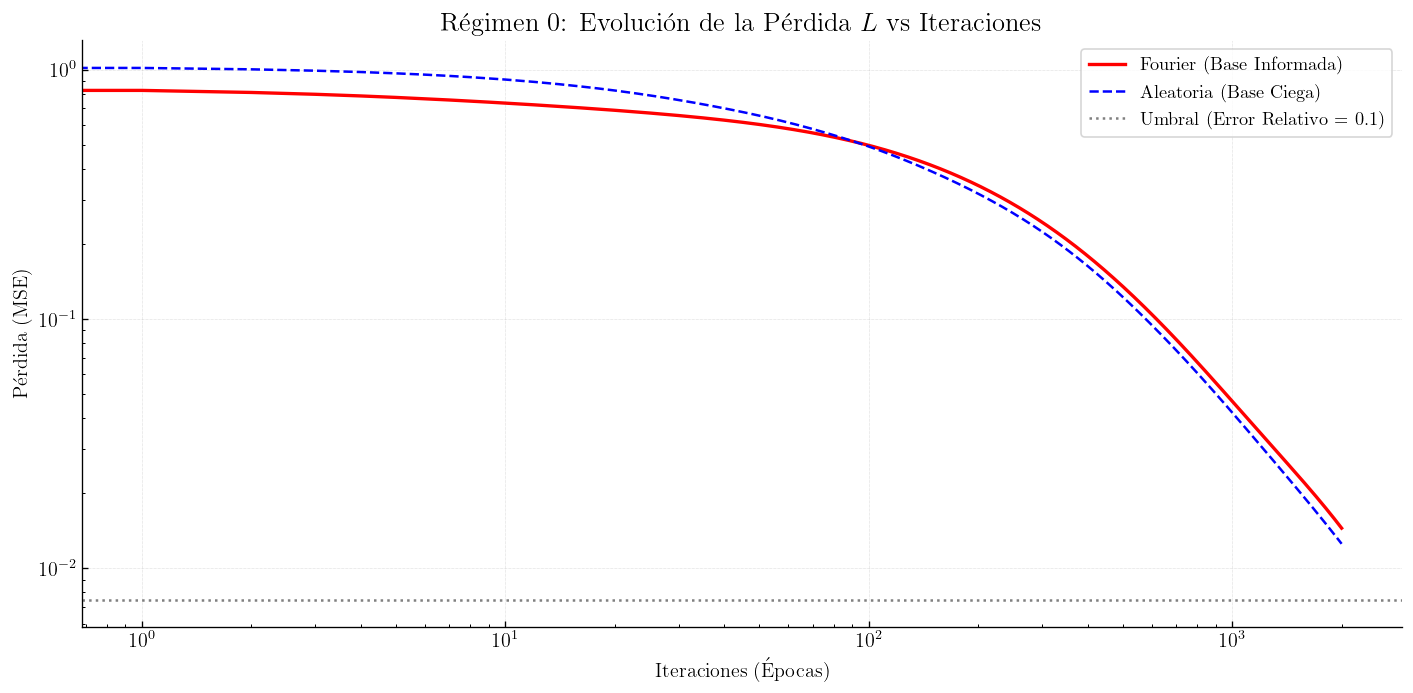


Análisis de Convergencia (Régimen 2 - Difícil)
-------------------------------------------------------
Iteraciones para Error Relativo < 0.1:
  -> Inicialización Fourier:  No alcanzó el umbral
  -> Inicialización Aleatoria: No alcanzó el umbral



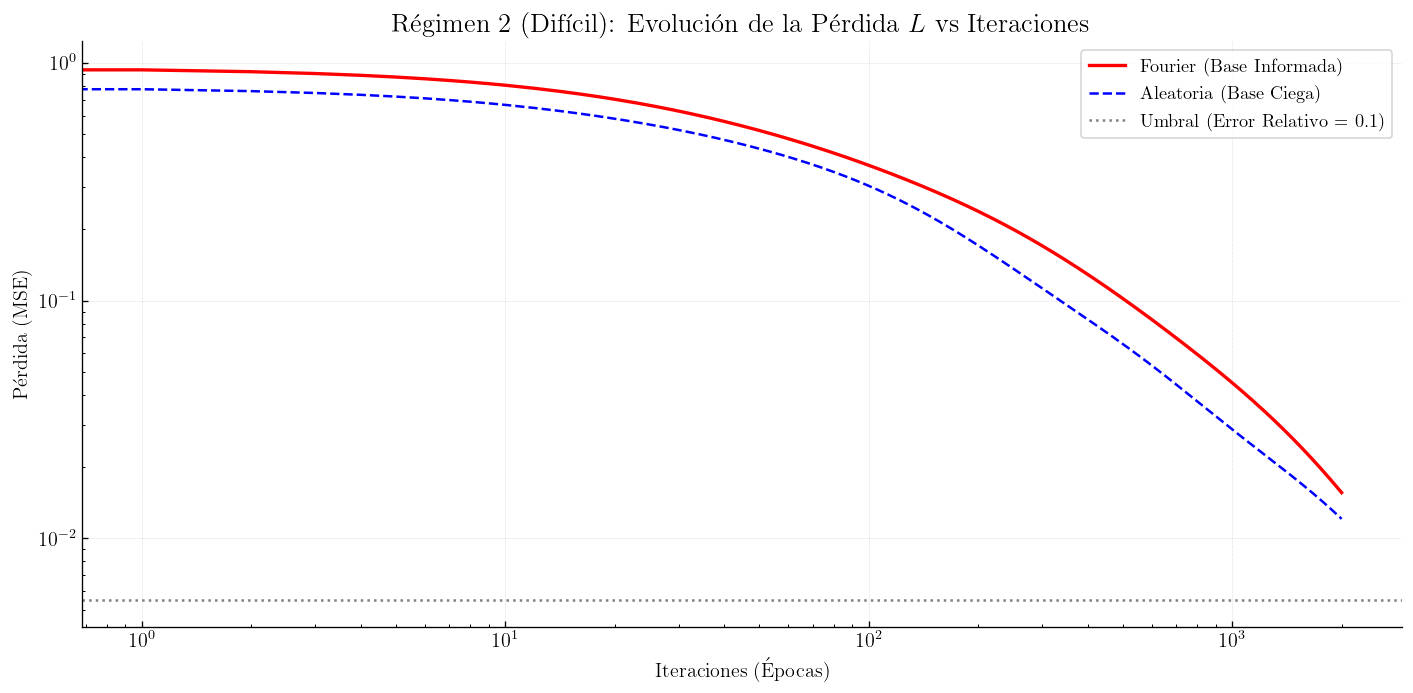

In [14]:
##Fase n°4 - Comparación de la perdida de erro entre las redes

import numpy as np
import matplotlib.pyplot as plt

# --- Análisis para el Régimen 0 ---

# 1. Convertir a arrays de NumPy estándar
loss_fourier_np_r0 = np.array(loss_fourier_r0)
loss_random_np_r0 = np.array(loss_random_r0)

# 2. Calculo del error relativo global para Régimen 0
N_total_r0 = X_regimen_0.size
norm_X_r0 = np.linalg.norm(X_regimen_0)

rel_error_history_fourier_r0 = np.sqrt(loss_fourier_np_r0 * N_total_r0) / norm_X_r0
rel_error_history_random_r0 = np.sqrt(loss_random_np_r0 * N_total_r0) / norm_X_r0

# 3. Encontrar la iteración donde el error relativo baja de 0.1
umbral = 0.1

def encontrar_iteracion_umbral(historial, umbral):
    iteraciones = np.where(historial < umbral)[0]
    return iteraciones[0] if len(iteraciones) > 0 else None

iter_fourier_r0 = encontrar_iteracion_umbral(rel_error_history_fourier_r0, umbral)
iter_random_r0 = encontrar_iteracion_umbral(rel_error_history_random_r0, umbral)

print("Análisis de Convergencia (Régimen 0)")
print("-" * 55)
print(f"Iteraciones para Error Relativo < {umbral}:")
print(f"  -> Inicialización Fourier:  {iter_fourier_r0 if iter_fourier_r0 is not None else 'No alcanzó el umbral'}")
print(f"  -> Inicialización Aleatoria: {iter_random_r0 if iter_random_r0 is not None else 'No alcanzó el umbral'}\n")

# 4. Visualización para Régimen 0
plt.figure(figsize=(12, 6))

# loglog
plt.loglog(loss_fourier_np_r0, label='Fourier (Base Informada)', color='red', linewidth=2)
plt.loglog(loss_random_np_r0, label='Aleatoria (Base Ciega)', color='blue', linestyle='--', linewidth=1.5)

# Línea horizontal para marcar el MSE equivalente al umbral de error relativo 0.1
mse_umbral_r0 = ((umbral * norm_X_r0) ** 2) / N_total_r0
plt.axhline(y=mse_umbral_r0, color='gray', linestyle=':', label=f'Umbral (Error Relativo = {umbral})')

# Marcadores para los puntos donde cruzan el umbral
if iter_fourier_r0 is not None:
    plt.scatter(iter_fourier_r0, loss_fourier_np_r0[iter_fourier_r0], color='red', zorder=5)
if iter_random_r0 is not None:
    plt.scatter(iter_random_r0, loss_random_np_r0[iter_random_r0], color='blue', zorder=5)

plt.title('Régimen 0: Evolución de la Pérdida $L$ vs Iteraciones', fontsize=16)
plt.xlabel('Iteraciones (Épocas)', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Análisis para el Régimen 2 (Difícil) ---

# 1. Convertir a arrays de NumPy estándar
loss_fourier_np_r2 = np.array(loss_fourier_r2)
loss_random_np_r2 = np.array(loss_random_r2)

# 2. Calculo del error relativo global para Régimen 2
N_total_r2 = X_regimen_2.size
norm_X_r2 = np.linalg.norm(X_regimen_2)

rel_error_history_fourier_r2 = np.sqrt(loss_fourier_np_r2 * N_total_r2) / norm_X_r2
rel_error_history_random_r2 = np.sqrt(loss_random_np_r2 * N_total_r2) / norm_X_r2

# 3. Encontrar la iteración donde el error relativo baja de 0.1
iter_fourier_r2 = encontrar_iteracion_umbral(rel_error_history_fourier_r2, umbral)
iter_random_r2 = encontrar_iteracion_umbral(rel_error_history_random_r2, umbral)

print("\nAnálisis de Convergencia (Régimen 2 - Difícil)")
print("-" * 55)
print(f"Iteraciones para Error Relativo < {umbral}:")
print(f"  -> Inicialización Fourier:  {iter_fourier_r2 if iter_fourier_r2 is not None else 'No alcanzó el umbral'}")
print(f"  -> Inicialización Aleatoria: {iter_random_r2 if iter_random_r2 is not None else 'No alcanzó el umbral'}\n")

# 4. Visualización para Régimen 2
plt.figure(figsize=(12, 6))

# loglog
plt.loglog(loss_fourier_np_r2, label='Fourier (Base Informada)', color='red', linewidth=2)
plt.loglog(loss_random_np_r2, label='Aleatoria (Base Ciega)', color='blue', linestyle='--', linewidth=1.5)

# Línea horizontal para marcar el MSE equivalente al umbral de error relativo 0.1
mse_umbral_r2 = ((umbral * norm_X_r2) ** 2) / N_total_r2
plt.axhline(y=mse_umbral_r2, color='gray', linestyle=':', label=f'Umbral (Error Relativo = {umbral})')

# Marcadores para los puntos donde cruzan el umbral
if iter_fourier_r2 is not None:
    plt.scatter(iter_fourier_r2, loss_fourier_np_r2[iter_fourier_r2], color='red', zorder=5)
if iter_random_r2 is not None:
    plt.scatter(iter_random_r2, loss_random_np_r2[iter_random_r2], color='blue', zorder=5)

plt.title('Régimen 2 (Difícil): Evolución de la Pérdida $L$ vs Iteraciones', fontsize=16)
plt.xlabel('Iteraciones (Épocas)', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Análisis de Compresión (Capa Fourier)
----------------------------------------
Coeficientes necesarios para capturar >= 90% de la energía: 5 (de 60)


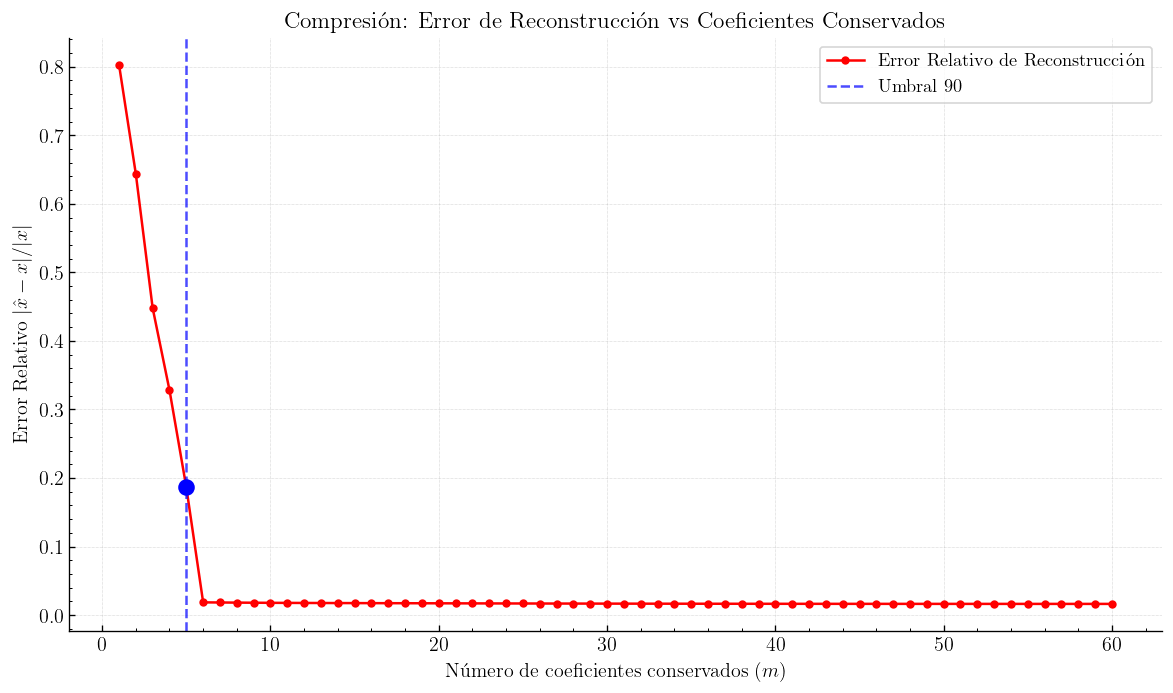

In [16]:
##Fase n°5 - Compresion

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

# 1. Tomar una señal del régimen 0 y la matriz W1 inicial (Fourier pura)
original_signal = X_regimen_0[0]

# Usamos los parámetros iniciales generados por init_fourier (antes de entrenar)
W1_fourier = params_fourier_r0[0]

# 2. Proyectar la señal en la capa Fourier para obtener los coeficientes (c = W1 * x)
coeficientes = jnp.dot(W1_fourier, original_signal)

# 3. Ordenar los coeficientes por magnitud (valor absoluto)
magnitudes = jnp.abs(coeficientes)
indices_ordenados = jnp.argsort(magnitudes)[::-1] # De mayor a menor

# 4. Preparar arreglos y herramientas matemáticas
errores_reconstruccion = []
energias_retenidas = []
energia_total_senal = jnp.sum(original_signal**2)

# Usamos la pseudo-inversa de W1 para mapear los coeficientes de vuelta a la señal en el tiempo
W1_pinv = jnp.linalg.pinv(W1_fourier)
num_coeficientes_lista = np.arange(1, len(coeficientes) + 1)

# 5. Iterar: Reconstruir la señal usando desde 1 hasta los 60 coeficientes
for m in num_coeficientes_lista:
    # Mantener solo los top 'm' coeficientes, hacer cero el resto
    c_comprimido = np.zeros_like(coeficientes)
    indices_top_m = indices_ordenados[:m]
    c_comprimido[indices_top_m] = coeficientes[indices_top_m]

    # Reconstruir la señal a partir de los coeficientes comprimidos
    reconstruccion_m = jnp.dot(W1_pinv, c_comprimido)

    # Calcular error de reconstrucción relativo |x_hat - x| / |x|
    error_rel = jnp.linalg.norm(reconstruccion_m - original_signal) / jnp.linalg.norm(original_signal)
    errores_reconstruccion.append(float(error_rel))

    # Calcular energía retenida (Energía reconstruida / Energía original)
    energia_m = jnp.sum(reconstruccion_m**2) / energia_total_senal
    energias_retenidas.append(float(energia_m))

errores_reconstruccion = np.array(errores_reconstruccion)
energias_retenidas = np.array(energias_retenidas)

# 6. Responder a la pregunta: ¿Cuántos coeficientes bastan para el 90% de energía?
umbral_energia = 0.90
indices_sobre_umbral = np.where(energias_retenidas >= umbral_energia)[0]
coefs_necesarios = indices_sobre_umbral[0] + 1 if len(indices_sobre_umbral) > 0 else None

print("Análisis de Compresión (Capa Fourier)")
print("-" * 40)
print(f"Coeficientes necesarios para capturar >= {umbral_energia*100:.0f}% de la energía: {coefs_necesarios} (de {len(coeficientes)})")

# 7. Visualización Científica
plt.figure(figsize=(10, 6))

# Graficar el error de reconstrucción
plt.plot(num_coeficientes_lista, errores_reconstruccion, label='Error Relativo de Reconstrucción', color='red', marker='o', markersize=4)

# Marcar el punto donde se alcanza el 90% de la energía
if coefs_necesarios:
    error_en_umbral = errores_reconstruccion[coefs_necesarios - 1]
    plt.axvline(x=coefs_necesarios, color='blue', linestyle='--', alpha=0.7,
                label=f'Umbral 90% Energía ($m={coefs_necesarios}$ coeficientes)')
    plt.scatter(coefs_necesarios, error_en_umbral, color='blue', s=80, zorder=5)

plt.title('Compresión: Error de Reconstrucción vs Coeficientes Conservados', fontsize=14)
plt.xlabel('Número de coeficientes conservados ($m$)', fontsize=12)
plt.ylabel(r'Error Relativo $|\hat{x} - x| / |x|$', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()